# Training — experiments as data

**Reads:** `data/<DATASET>/split/`, `configs/augment.json` (optional) · **Writes:** `runs/<run_id>/`.

All training logic lives in `thai_char_cnn.train.fit`; this notebook only says *which* runs to
make and reads their results. Each experiment is one row of overrides on a shared `BASE`.

A run is cached under a hash of its full config, seed, `split_id` and `train_version` (a hand-bumped
version of the training code, see `thai_char_cnn.train`). Rerunning the notebook loads finished runs
instead of retraining them, so adding a row trains only that row. Adding a model or a new config key
leaves existing runs alone; a change to what an existing config produces bumps `TRAIN_VERSION`, and
`VERIFY=1` catches a forgotten bump.

Two switches, both off by default:

| env var | effect |
| --- | --- |
| `RETRAIN=1` | ignore the cache and retrain every row (overwrites its run) |
| `VERIFY=1` | §5 retrains the first run into a scratch folder and checks it matches the cached one |
| `EPOCHS=n` | smoke run with `n` epochs (a separate run, since epochs are part of the hash) |

### What the score is, and isn't

- The score is **val macro-F1 over validated classes**: per-class F1 averaged with equal weight, over
  the classes `03_split` could give enough val images. Accuracy is shown too, but with this
  imbalance it mostly reflects the ten biggest classes.
- Val is chosen **by writer**, so it measures unseen handwriting. It is also used for early
  stopping and for choosing between experiments, so it is optimistic. The instructor's hidden test
  set is the real test, and nothing here is called "test".
- Classes flagged *not validated* are trained on, but nothing measures them. They are listed below.

## 1 · Setup and data check

**What:** load the current split and check it passed its own self-checks, then show what the
training pipeline actually feeds the model, augmentation included.

**Why the montage is here:** the augmentation preview (`05_augment_preview.py`) is deferred. Until
it exists, this is the only look at what augmentation does to the glyphs. Augmentation is tiered
per class (`thai_char_cnn.augment.TIER_GROUPS`): robust glyphs get the full range, hook/loop pairs,
ascender/descender letters, marks and the า/ๅ pair get progressively less. Each row's label shows
the character and its tiers.

In [1]:
import json
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from matplotlib import font_manager
from PIL import Image

from thai_char_cnn.augment import build_train_transform, load_augment_config
from thai_char_cnn.data import SplitData
from thai_char_cnn.metrics import top_confused
from thai_char_cnn.paths import CONFIGS, FONT, RAW, SPLIT_DIR
from thai_char_cnn.preprocess import letterbox
from thai_char_cnn.train import DEFAULT_CONFIG, TRAIN_VERSION, fit, load_runs, resolve_config

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)
font_manager.fontManager.addfont(str(FONT))
THAI = font_manager.FontProperties(fname=str(FONT), size=16)

split_run = json.loads((SPLIT_DIR / "run.json").read_text())
SPLIT_ID = split_run["split_id"]
failed = [k for k, v in split_run["checks"].items() if v != "PASS"]
assert not failed, f"03_split self-checks failed: {failed}"

aug_path = CONFIGS / "augment.json"
AUG = load_augment_config(aug_path)
print(f"split_id     : {SPLIT_ID}   ({split_run['generated_at']})")
print(f"augmentation : {'configs/augment.json' if aug_path.exists() else 'defaults (no configs/augment.json yet)'}")
print(f"               overrides: profiles={AUG.profiles or '{}'}, tiers={AUG.tiers or '{}'}")
print(f"device       : {'cuda — ' + torch.cuda.get_device_name() if torch.cuda.is_available() else 'cpu'}")

data = SplitData(DEFAULT_CONFIG["img_size"], DEFAULT_CONFIG["preprocess"])
print(f"\ntrain images : {len(data.idx['train']):,}")
print(f"val images   : {len(data.idx['val']):,}")
print(f"pixel mean/std (train only): {data.pixel_mean:.4f} / {data.pixel_std:.4f}")
classes = data.classes
print(f"classes      : {classes.status.value_counts().to_dict()}")
print(f"not validated: {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'not_validated'].itertuples())}")
print(f"weak (val<5) : {', '.join(f'{r.folder} {r.character}' for r in classes[classes.status == 'weak'].itertuples())}")

split_id     : d0a0d7ada85a   (2026-09-24T15:27:17+00:00)
augmentation : configs/augment.json
               overrides: profiles={}, tiers={'จ': [4], 'ด': [4], 'ต': [4], 'ว': [5], 'า': [5], 'ใ': [5]}
device       : cuda — NVIDIA GeForce RTX 3060



train images : 48,400
val images   : 11,996
pixel mean/std (train only): 0.5647 / 0.4445
classes      : {'validated': 56, 'not_validated': 11, 'weak': 5}
not validated: 163 ฃ, 177 ฑ, 196 ฤ, 204 ฬ, 206 ฮ, 214 ึ, 244 ๔, 245 ๕, 246 ๖, 247 ๗, 249 ๙
weak (val<5) : 189 ฝ, 207 ฯ, 225 แ, 234 ๊, 248 ๘


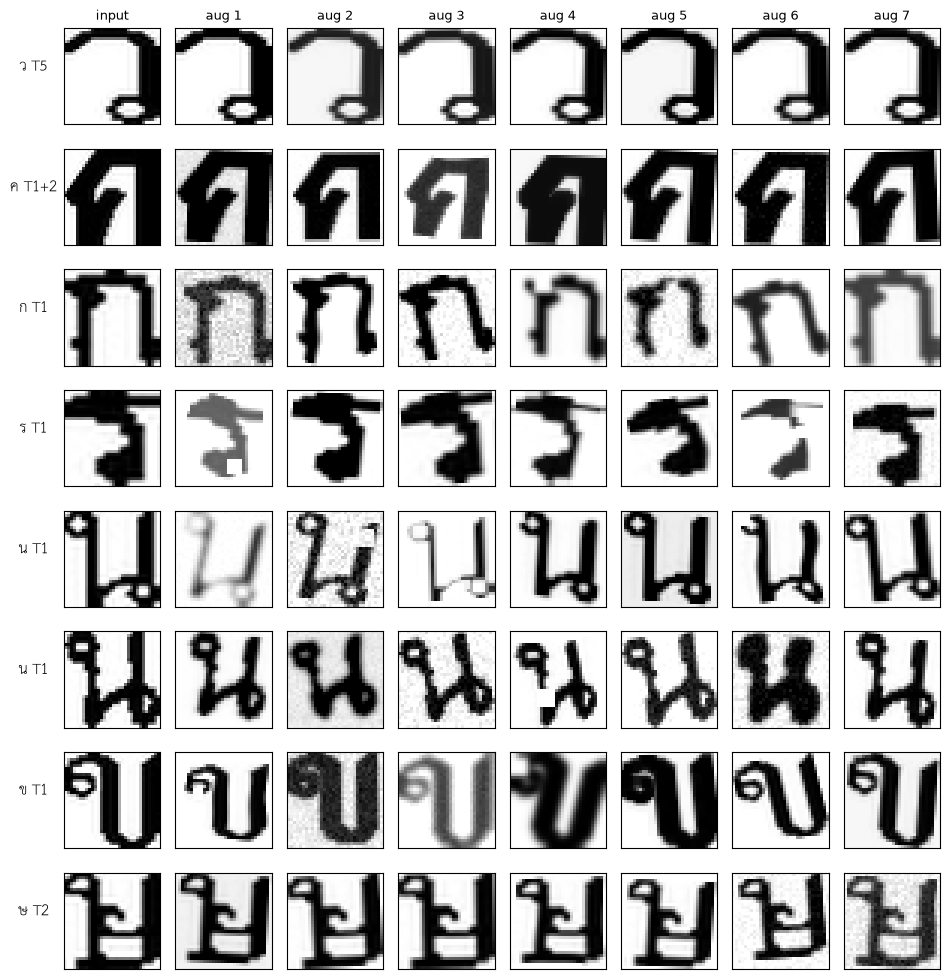

In [2]:
# first column: the model input as-is; the rest: independent draws of the train transform
N_ROWS, N_DRAWS = 8, 7
torch.manual_seed(0)
rng = np.random.default_rng(0)
pick = rng.choice(data.idx["train"], N_ROWS, replace=False)
tf = build_train_transform(AUG, classes.character.tolist())
TIERS = AUG.resolved_tiers()
fig, ax = plt.subplots(N_ROWS, N_DRAWS + 1, figsize=(1.2 * (N_DRAWS + 1), 1.25 * N_ROWS))
for r, j in enumerate(pick):
    px = data.pixels[j]
    for c in range(N_DRAWS + 1):
        img = px if c == 0 else tf(px, int(data.y[j]))
        ax[r, c].imshow(img[0], cmap="gray", vmin=0, vmax=255)
        ax[r, c].set_xticks([])
        ax[r, c].set_yticks([])
    ch = classes.character.iloc[int(data.y[j])]
    ax[r, 0].set_ylabel(f"{ch} T{'+'.join(map(str, TIERS[ch]))}", fontproperties=THAI, rotation=0, labelpad=22)
ax[0, 0].set_title("input", fontsize=9)
for c in range(1, N_DRAWS + 1):
    ax[0, c].set_title(f"aug {c}", fontsize=9)
plt.tight_layout()
plt.show()

## 2 · Experiment table

`BASE` is shared by every run; `EXPERIMENTS` maps a name to the overrides that make it different.
Anything not listed takes `thai_char_cnn.train.DEFAULT_CONFIG`.

The default input is square `stretch`, which beat aspect-preserving `letterbox` on every seed, before
and after the data audit. `stretch+augment` adds tiered augmentation (`augment=True`, see §1) and is
the recommended model; `stretch` stays as its no-augmentation control, since the two are still tied.

`resnet18@64` and `resnet18-pretrained@64` ask whether a bigger backbone helps, and separately
whether ImageNet weights do. Both use torchvision's ResNet-18 with a one-channel stem on 64 px
input (its stem downsamples 4x, too much for 32 px) and tiered augmentation, at `lr=1e-3` so
fine-tuning doesn't overwrite the pretrained features. They differ only in `pretrained`: random
init vs the `IMAGENET1K_V1` weights, with the RGB stem kernel summed to one channel. Compare both
with `stretch+augment`. Neither beats it.

Rows are kept only while they answer an open question. Retired experiments, and the results that
retired them, are recorded in `reports/training-decisions.md`; the final comparison across all of
them is `reports/final-report.md`. Each configuration uses three seeds because small single-seed
gaps are not decision-quality evidence.

`EPOCHS`, `RETRAIN` and `VERIFY` come from the environment (see the top of the notebook), so a
command-line run can set them without editing the notebook.

In [3]:
BASE = dict(epochs=int(os.environ.get("EPOCHS", DEFAULT_CONFIG["epochs"])))
SEEDS = [42, 137, 271]
RETRAIN = os.environ.get("RETRAIN") == "1"
VERIFY = os.environ.get("VERIFY") == "1"

# ResNet-18 at 64 px: identical recipe, so the two rows differ only in their initial weights
RESNET = dict(model="resnet18", img_size=64, augment=True, lr=1e-3)

EXPERIMENTS = {
    "stretch": {},
    "stretch+augment": dict(augment=True),
    "resnet18@64": RESNET,
    "resnet18-pretrained@64": RESNET | dict(pretrained="IMAGENET1K_V1"),
}

table = pd.DataFrame({name: DEFAULT_CONFIG | BASE | ov for name, ov in EXPERIMENTS.items()}).T
varying = [c for c in table.columns if table[c].astype(str).nunique() > 1]
print(f"shared      : {({k: v for k, v in (DEFAULT_CONFIG | BASE).items() if k not in varying})}")
print(f"seeds       : {SEEDS}")
print(f"train ver.  : {TRAIN_VERSION}")
print(f"RETRAIN={RETRAIN}  VERIFY={VERIFY}")
table[varying] if varying else table[[]].assign(overrides="none — baseline only")

shared      : {'pretrained': None, 'freeze_through': None, 'mlp_hidden': None, 'width': 32, 'dropout': 0.3, 'use_geometry': False, 'preprocess': 'stretch', 'sampler': 'none', 'epochs': 40, 'batch_size': 256, 'weight_decay': 0.0005, 'warmup_epochs': 1, 'label_smoothing': 0.0, 'patience': 8, 'seed': 42, 'amp': True}
seeds       : [42, 137, 271]
train ver.  : 1
RETRAIN=False  VERIFY=False


,model,img_size,augment,lr
stretch,small_cnn,32,False,0.003
stretch+augment,small_cnn,32,True,0.003
resnet18@64,resnet18,64,True,0.001
resnet18-pretrained@64,resnet18,64,True,0.001


## 3 · Train (or load)

One loop. A finished run is loaded from `runs/`; anything new is trained, and with `RETRAIN=1`
everything is. On the RTX 3060 a baseline epoch takes about two seconds, a ResNet-18 epoch at 64 px about
nine (augmentation on the CPU is the bottleneck), so a ResNet run takes up to about 6 minutes.

In [4]:
RUN_DIRS = {}
for name, overrides in EXPERIMENTS.items():
    for seed in SEEDS:
        RUN_DIRS.setdefault(name, []).append(fit(BASE | overrides | dict(name=name, seed=seed),
                                                 force=RETRAIN))

[stretch] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/28d32bd7713a
[stretch] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/fc42a6285144
[stretch] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/c324b6b57c75
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/1e94eb59c37d
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/c80f69cf5af9
[stretch+augment] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/f4747ccb4bb3
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/d12f65132771
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/95033e7c4f6d
[resnet18@64] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/bad6a5679718
[resnet18-pretrained@64] cached -> /mnt/srv/home/whats/cnn/repo/.claude/worktrees/resnet18/runs/583115bf51ce
[resnet18

## 4 · Leaderboard

Ranked by val macro-F1 over validated classes, mean ± standard deviation across seeds. Only runs in
the current experiment table are ranked, and those are by construction on the current `split_id`
and `train_version`. Other runs on disk are listed below as a record, not compared, with the reason: a
different split means a different val set, and different code means a different pipeline.

In [5]:
runs = load_runs()
current_ids = {p.name for dirs in RUN_DIRS.values() for p in dirs}
cur = runs[runs.run_id.isin(current_ids)].copy()
name_of = {p.name: n for n, dirs in RUN_DIRS.items() for p in dirs}
cur["experiment"] = cur.run_id.map(name_of)

board = (cur.groupby("experiment")
         .agg(seeds=("seed", "size"), macro_f1=("val_macro_f1", "mean"), macro_f1_sd=("val_macro_f1", "std"),
              macro_f1_all=("val_macro_f1_all", "mean"), val_acc=("val_acc", "mean"),
              best_epoch=("best_epoch", "mean"), trainable=("n_trainable", "first"), minutes=("train_time_s", lambda s: s.sum() / 60))
         .sort_values("macro_f1", ascending=False).round(4))
print(f"split {SPLIT_ID} · headline = macro-F1 over {int((classes.status == 'validated').sum())} validated classes\n")
display(board)

other = runs[~runs.run_id.isin(current_ids)]
if len(other):
    other = other.assign(reason=np.select(
        [other.split_id != SPLIT_ID, other["train_version"] != resolve_config({})["train_version"]],
        ["older split", "older code"], "not in the experiment table"))
    print(f"\nnot ranked: {len(other)} other run(s) on disk")
    display(other[["run_id", "name", "reason", "split_id", "train_version", "cfg.code_hash", "cfg.epochs", "seed", "val_macro_f1"]])

split d0a0d7ada85a · headline = macro-F1 over 56 validated classes



,seeds,macro_f1,macro_f1_sd,macro_f1_all,val_acc,best_epoch,trainable,minutes
experiment,,,,,,,,
stretch+augment,3,0.9894,0.0013,0.9870,0.9902,22.6667,NaN,5.5033
stretch,3,0.9889,0.0020,0.9886,0.9904,21.6667,NaN,2.9917
resnet18@64,3,0.9884,0.0029,0.9883,0.9883,15.0000,NaN,9.8667
resnet18-pretrained@64,3,0.9872,0.0004,0.9850,0.9888,17.6667,11207176.0,11.1900



not ranked: 128 other run(s) on disk


,run_id,name,reason,split_id,train_version,cfg.code_hash,cfg.epochs,seed,val_macro_f1
0,01cbfd119b68,letterbox-cleaned,older code,d0a0d7ada85a,,b41693cfacf2,40,137,0.984108
1,04a3a9094f09,stretch+augment-uniform,not in the experiment table,d0a0d7ada85a,1.p2,fdba95a2a0a6,40,271,0.983987
2,058bab03c7cb,resnet18-pretrained@64,older code,d0a0d7ada85a,,f25285474a8f,40,137,0.987525
3,05b212628308,baseline,older split,49bb16a21863,,NaN,40,42,0.973850
4,06e4c16588c5,stretch+augment-ramp,not in the experiment table,d0a0d7ada85a,1.p2,a8910995d481,40,137,0.987850
...,...,...,...,...,...,...,...,...,...
133,f2fcf48bba55,letterbox+geometry,older split,49bb16a21863,,b41693cfacf2,40,42,0.977198
135,f4eaddcaf8c9,letterbox+geometry,not in the experiment table,d0a0d7ada85a,1.p2,fdba95a2a0a6,40,42,0.986786
136,fa72fa08ea40,resnet18-pretrained-frozen@64,not in the experiment table,d0a0d7ada85a,1.p2,ac396e469e8b,40,42,0.854301
137,faa83bbdc479,letterbox+augment-uniform,older split,49bb16a21863,,b41693cfacf2,40,271,0.971060


## 5 · Reproducibility check (`VERIFY=1`)

**What:** retrain the first run of the first experiment from scratch into a scratch folder and
compare it with the cached run: metrics, per-epoch history, every val prediction, and the weights.

**Why:** the cache is only trustworthy if training is deterministic. Seeds, cuDNN's deterministic
mode and seeded data-loader workers are meant to make it so; this measures whether they do.

**How to read it:**

- **exact** — identical weights. The cache is a faithful stand-in for retraining.
- **drift** — macro-F1 within 0.005. Expected after a change of GPU, driver, PyTorch/CUDA version
  or `num_workers`, which reorder floating-point work. Not a bug; worth a note.
- **mismatch** — a larger gap. Something the run hash doesn't capture changed; investigate before
  trusting any cached number.

It costs one extra training run, so it's off unless asked for.

In [6]:
DRIFT_TOL = 0.005
if not VERIFY:
    print("skipped (set VERIFY=1 to retrain and compare)")
else:
    ref_name = next(iter(EXPERIMENTS))
    ref = RUN_DIRS[ref_name][0]
    ref_cfg = BASE | EXPERIMENTS[ref_name] | dict(name=ref_name, seed=SEEDS[0])
    with tempfile.TemporaryDirectory() as tmp:
        new = fit(ref_cfg, data=data, runs_dir=Path(tmp), verbose=False)
        ma, mb = (json.loads((d / "metrics.json").read_text()) for d in (ref, new))
        ha, hb = (pd.read_csv(d / "history.csv") for d in (ref, new))
        pa, pb = (pd.read_csv(d / "val_predictions.csv") for d in (ref, new))
        sa, sb = (torch.load(d / "model.pt", weights_only=False)["state_dict"] for d in (ref, new))
    same_id = new.name == ref.name
    dw = max(float((sa[k].float() - sb[k].float()).abs().max()) for k in sa)
    df1 = abs(ma["val_macro_f1"] - mb["val_macro_f1"])
    hcols = ["train_loss", "val_loss", "val_macro_f1"]
    verdict = ("exact" if same_id and dw == 0 else "drift" if same_id and df1 <= DRIFT_TOL else "mismatch")

    print(f"retrained {ref_name!r} (run {ref.name}) from scratch in {mb['train_time_s']:.0f}s")
    print(f"  same run id          : {same_id}")
    print(f"  val macro-F1         : cached {ma['val_macro_f1']:.6f}  retrained {mb['val_macro_f1']:.6f}")
    print(f"  best epoch           : cached {ma['best_epoch']}  retrained {mb['best_epoch']}")
    print(f"  history max |diff|   : {float((ha[hcols] - hb[hcols]).abs().max().max()) if len(ha) == len(hb) else 'length differs'}")
    print(f"  val predictions diff : {int((pa.pred_idx != pb.pred_idx).sum())} of {len(pa):,}")
    print(f"  weights max |diff|   : {dw}")
    print(f"\nverdict: {verdict.upper()}")
    assert verdict != "mismatch", "retraining does not reproduce the cached run"

skipped (set VERIFY=1 to retrain and compare)


## 6 · Deep dive

Everything below reads the run named by `FOCUS` (its first seed). Change `FOCUS` to look at another
experiment; nothing else needs editing.

- **Per-class F1**, weakest first. Grey bars are *weak* classes (fewer than 5 val images); their F1 is
  close to noise. Not-validated classes have no val images and are absent.
- **Top confused pairs.** These feed the next ruling pass: a pair confused in both directions is
  either genuinely similar glyphs or a labelling problem, and only looking at the images says which.
- **Error gallery**: the most confident mistakes, which are where label errors tend to hide.

stretch+augment  run 1e94eb59c37d  split d0a0d7ada85a
  val macro-F1 (validated classes) : 0.9893
  val macro-F1 (all with val)      : 0.9869
  val accuracy                     : 0.9917
  best epoch 35 of 40 run, 149s, 296,168 params


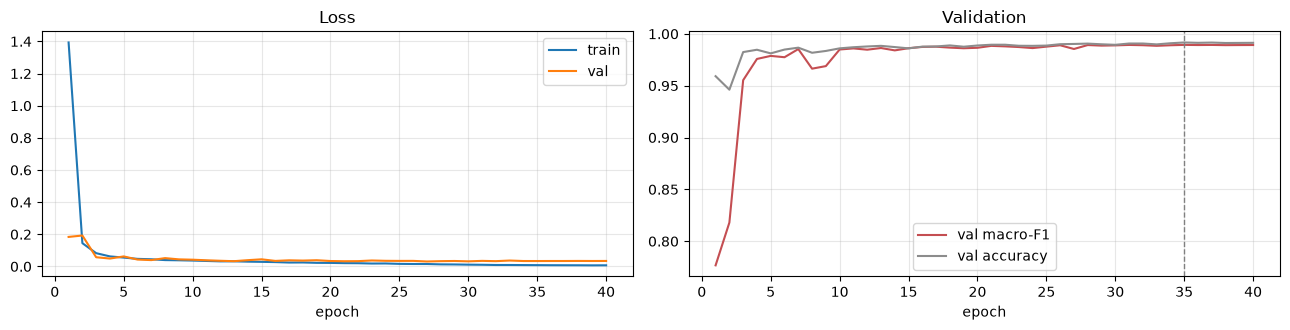

In [7]:
FOCUS = "stretch+augment"
run_dir = RUN_DIRS[FOCUS][0]
m = json.loads((run_dir / "metrics.json").read_text())
hist = pd.read_csv(run_dir / "history.csv")
pc = pd.read_csv(run_dir / "per_class.csv", keep_default_na=False, na_values=[""])
cm = np.load(run_dir / "confusion.npy")
preds = pd.read_csv(run_dir / "val_predictions.csv")

print(f"{FOCUS}  run {m['run_id']}  split {m['split_id']}")
print(f"  val macro-F1 (validated classes) : {m['val_macro_f1']:.4f}")
print(f"  val macro-F1 (all with val)      : {m['val_macro_f1_all']:.4f}")
print(f"  val accuracy                     : {m['val_acc']:.4f}")
print(f"  best epoch {m['best_epoch']} of {m['epochs_run']} run, {m['train_time_s']:.0f}s, {m['n_params']:,} params")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(hist.epoch, hist.train_loss, label="train")
ax[0].plot(hist.epoch, hist.val_loss, label="val")
ax[0].set(title="Loss", xlabel="epoch")
ax[0].legend()
ax[1].plot(hist.epoch, hist.val_macro_f1, color="#C44E52", label="val macro-F1")
ax[1].plot(hist.epoch, hist.val_acc, color="#8C8C8C", label="val accuracy")
ax[1].axvline(m["best_epoch"], ls="--", c="gray", lw=1)
ax[1].set(title="Validation", xlabel="epoch")
ax[1].legend()
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

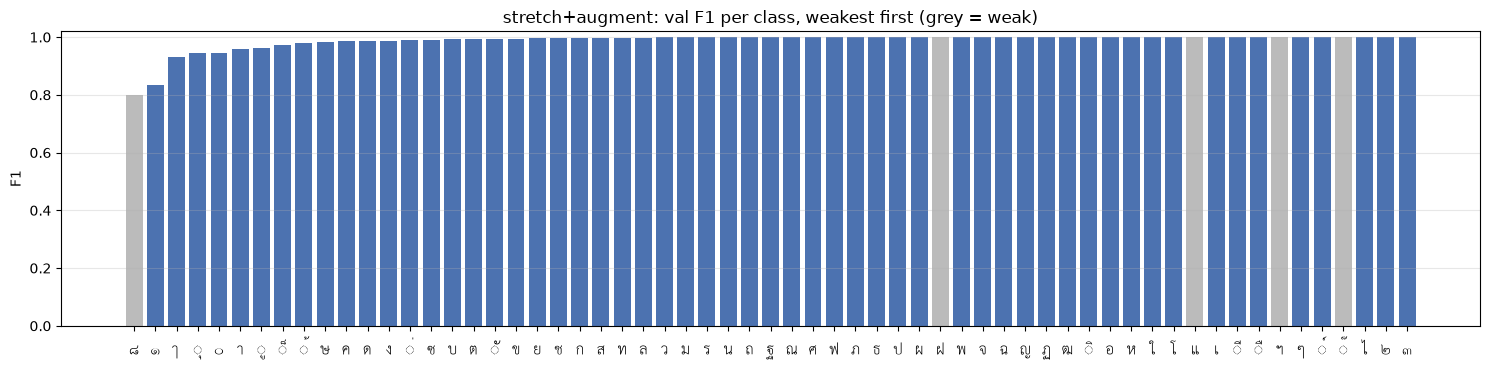

weakest 12 classes:


,class_idx,folder,character,status,train_n,support,precision,recall,f1
70,70,248,๘,weak,24,2,0.667,1.000,0.800
63,63,241,๑,validated,39,7,1.000,0.714,0.833
55,55,229,ๅ,validated,1069,405,0.942,0.919,0.930
48,48,216,ุ,validated,137,17,0.895,1.000,0.944
62,62,240,๐,validated,68,17,0.895,1.000,0.944
43,43,210,า,validated,3067,713,0.954,0.966,0.960
49,49,217,ู,validated,116,26,0.962,0.962,0.962
57,57,231,็,validated,99,19,1.000,0.947,0.973
59,59,233,้,validated,836,192,0.989,0.969,0.979
35,35,201,ษ,validated,203,62,0.969,1.000,0.984


In [8]:
shown = pc[pc.support > 0].sort_values("f1")
fig, ax = plt.subplots(figsize=(15, 3.8))
ax.bar(range(len(shown)), shown.f1, color=np.where(shown.status == "weak", "#BBBBBB", "#4C72B0"))
ax.set_xticks(range(len(shown)))
ax.set_xticklabels(shown.character, fontproperties=THAI)
ax.set(title=f"{FOCUS}: val F1 per class, weakest first (grey = weak)", ylabel="F1", ylim=(0, 1.02))
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("weakest 12 classes:")
shown.head(12)[["class_idx", "folder", "character", "status", "train_n", "support", "precision", "recall", "f1"]].round(3)

In [9]:
ch = classes.set_index("class_idx")
tc = top_confused(cm, 15)
tc["true"] = tc.true_idx.map(lambda i: f"{ch.folder[i]} {ch.character[i]}")
tc["predicted"] = tc.pred_idx.map(lambda i: f"{ch.folder[i]} {ch.character[i]}")
tc["reverse_count"] = [int(cm[p, t]) for t, p in zip(tc.true_idx, tc.pred_idx, strict=True)]
tc[["true", "predicted", "count", "share_of_true", "reverse_count"]].round(3)

,true,predicted,count,share_of_true,reverse_count
0,229 ๅ,210 า,32,0.079,23
1,210 า,229 ๅ,23,0.032,32
2,233 ้,209 ั,6,0.031,1
3,164 ค,180 ด,6,0.017,4
4,180 ด,164 ค,4,0.009,6
5,167 ง,181 ต,3,0.020,0
6,162 ข,186 บ,2,0.007,0
7,193 ม,186 บ,1,0.002,0
8,241 ๑,240 ๐,1,0.143,0
9,229 ๅ,244 ๔,1,0.002,0


val errors: 100 of 11,996 — the 32 most confident:


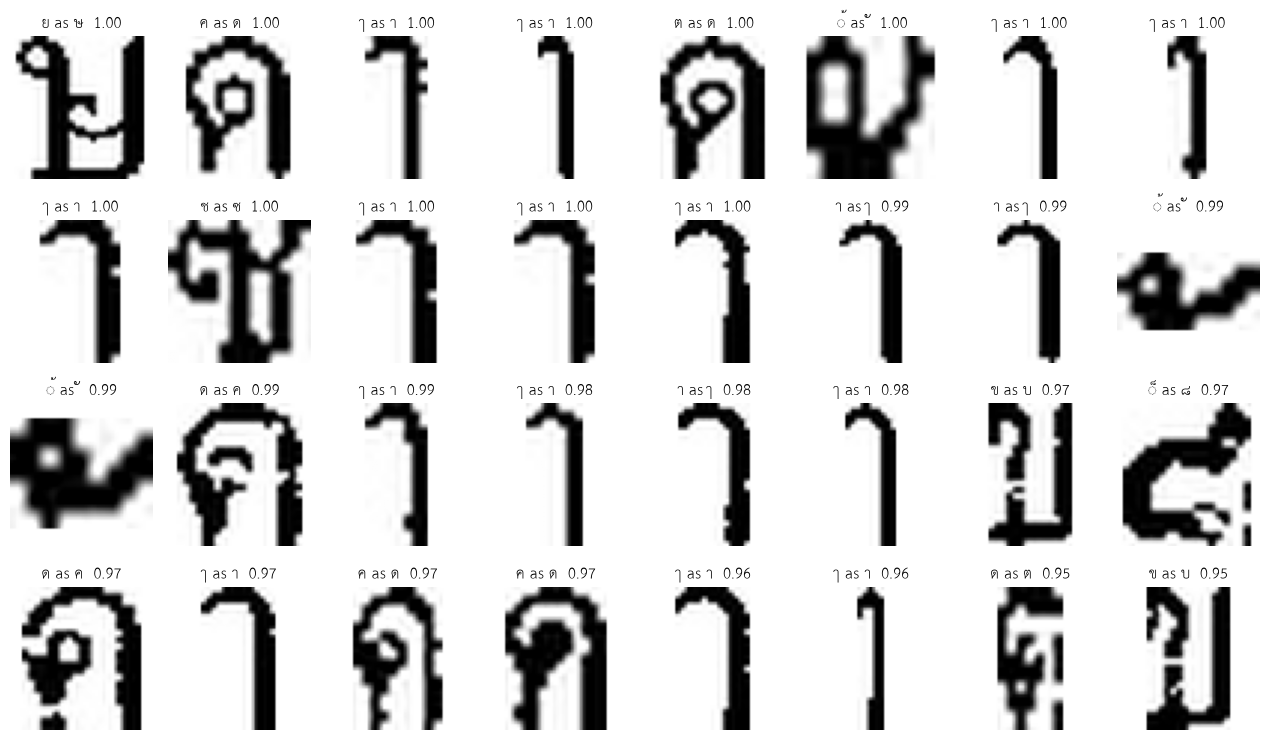

,path,writer_id,true,pred,p_pred,p_true
5835,194/be_018tg_7_188.jpg,be_018,194,201,1.0000,0.0000
1994,180/be_006sg_3_439.jpg,be_006,164,180,1.0000,0.0000
10332,210/be_018sg_6_36.jpg,be_018,229,210,1.0000,0.0000
9945,210/be_002tg_6_129.jpg,be_002,229,210,0.9997,0.0001
2332,181/be_002sg_9_37.jpg,be_002,181,180,0.9995,0.0005
8949,209/be_002tg_10_162.jpg,be_002,233,209,0.9989,0.0009
10276,210/be_016tg_9_345.jpg,be_016,229,210,0.9987,0.0013
9904,210/be_002sg_7_321.jpg,be_002,229,210,0.9984,0.0002
11259,229/be_006sg_1_462.jpg,be_006,229,210,0.9983,0.0016
1642,171/be_006sg_6_17.jpg,be_006,170,171,0.9979,0.0021


In [10]:
N_ERR = 32
err = preds[preds.true_idx != preds.pred_idx].sort_values("p_pred", ascending=False).head(N_ERR)
print(f"val errors: {int((preds.true_idx != preds.pred_idx).sum()):,} of {len(preds):,} — the {len(err)} most confident:")
cols = 8
fig, ax = plt.subplots(int(np.ceil(len(err) / cols)), cols, figsize=(1.6 * cols, 1.9 * np.ceil(len(err) / cols)),
                       squeeze=False)
for a in ax.ravel():
    a.axis("off")
for a, r in zip(ax.ravel(), err.itertuples(), strict=False):
    with Image.open(RAW / r.path) as im:
        a.imshow(letterbox(im.convert("L"), 48), cmap="gray", vmin=0, vmax=255)
    a.set_title(f"{ch.character[r.true_idx]} as {ch.character[r.pred_idx]}  {r.p_pred:.2f}", fontproperties=THAI)
plt.tight_layout()
plt.show()
err.assign(true=err.true_idx.map(ch.folder), pred=err.pred_idx.map(ch.folder))[
    ["path", "writer_id", "true", "pred", "p_pred", "p_true"]].head(12)